✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\40_regression_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\40_regression_3d.png


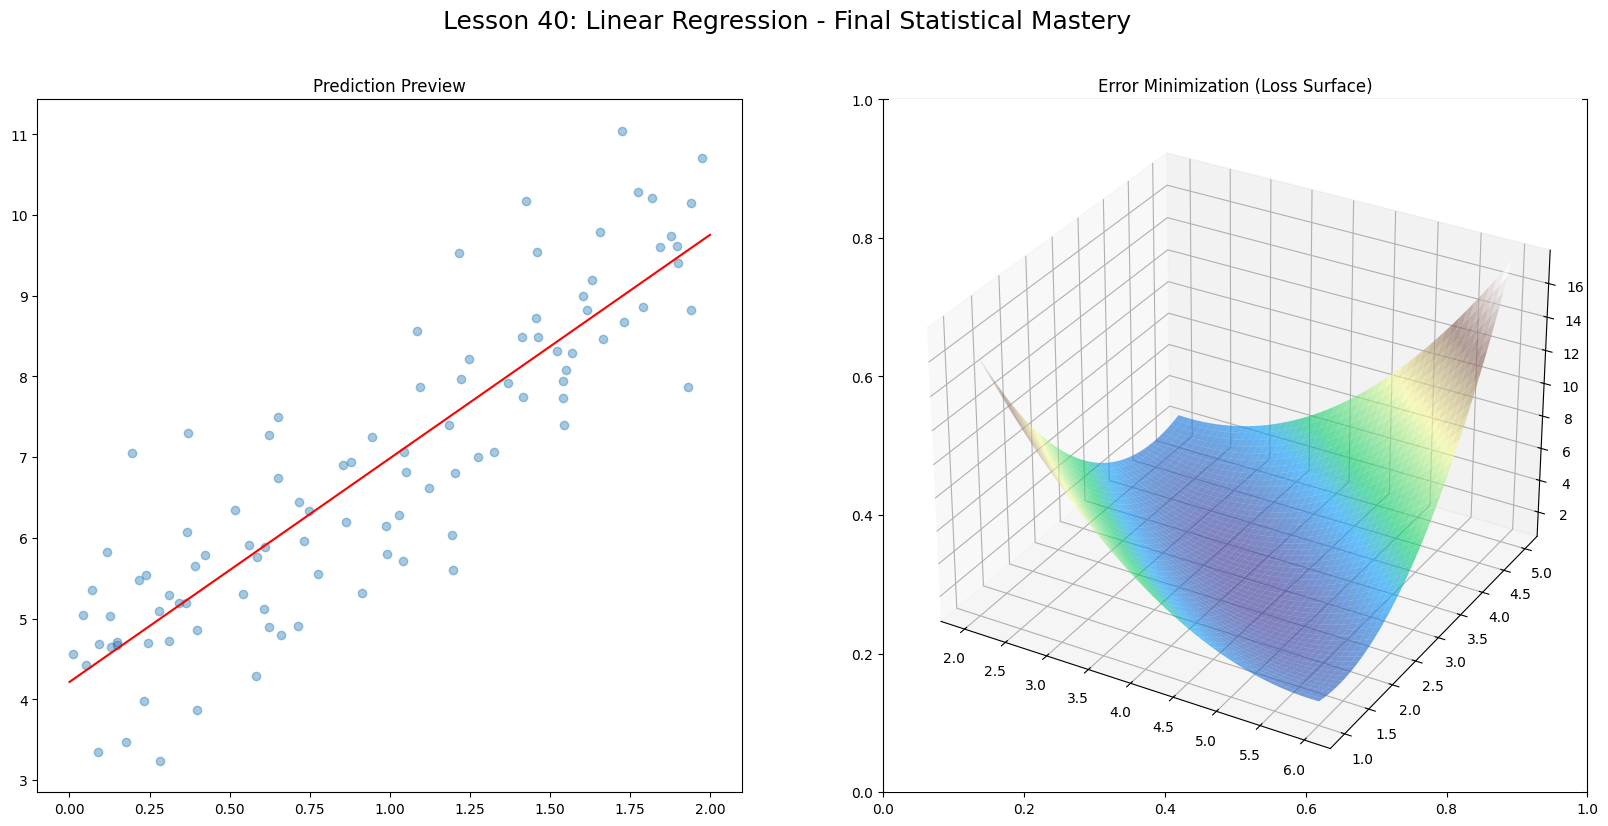

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import os

def run_regression_master():
    # --- YOL AYARI ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Veri Üretimi
    np.random.seed(42)
    X = 2 * np.random.rand(100, 1)
    y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise

    # 2. Model Eğitimi
    model = LinearRegression()
    model.fit(X, y)
    X_new = np.array([[0], [2]])
    y_predict = model.predict(X_new)

    # --- 📸 ASSET 1: SADECE 2D GRAFİK (40_regression_2d.png) ---
    fig2d, ax2d = plt.subplots(figsize=(10, 7))
    ax2d.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
    ax2d.plot(X_new, y_predict, 'r-', lw=3, label='Regression Line')
    
    ax2d.set_title(f"2D Linear Regression (R²: {model.score(X, y):.4f})", fontsize=14)
    ax2d.set_xlabel("Independent Variable (X)")
    ax2d.set_ylabel("Dependent Variable (y)")
    ax2d.legend()
    
    plt.savefig(os.path.join(asset_path, '40_regression_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\40_regression_2d.png")
    plt.close(fig2d)

    # --- 📸 ASSET 2: SADECE 3D GRAFİK (40_regression_3d.png) ---
    # Bu grafik "Loss Function" (MSE) manzarasını gösterir
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    intercept_range = np.linspace(2, 6, 50)
    slope_range = np.linspace(1, 5, 50)
    B0, B1 = np.meshgrid(intercept_range, slope_range)
    
    # Her (intercept, slope) çifti için MSE hesapla (Vektörize)
    # MSE = mean((y - (b0 + b1*x))^2)
    Z_mse = np.array([np.mean((y - (b0 + b1*X))**2) for b0, b1 in zip(np.ravel(B0), np.ravel(B1))])
    Z_mse = Z_mse.reshape(B0.shape)

    surf = ax3d.plot_surface(B0, B1, Z_mse, cmap='terrain', alpha=0.8, edgecolor='none')
    
    # En iyi noktayı (Optimal Beta) işaretle
    ax3d.scatter(model.intercept_, model.coef_[0], np.mean((y - model.predict(X))**2), 
                 color='red', s=100, label='Global Minimum (Optimal)')

    ax3d.set_title("3D Loss Function Surface (MSE)", fontsize=14)
    ax3d.set_xlabel('Intercept (β0)'); ax3d.set_ylabel('Slope (β1)'); ax3d.set_zlabel('Mean Squared Error')
    ax3d.legend()
    
    plt.savefig(os.path.join(asset_path, '40_regression_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\40_regression_3d.png")
    plt.close(fig3d)

    # --- 🖥️ DASHBOARD (Preview) ---
    fig_dash, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(20, 9))
    ax_l.scatter(X, y, alpha=0.4)
    ax_l.plot(X_new, y_predict, 'r-')
    ax_l.set_title("Prediction Preview")

    ax_r = fig_dash.add_subplot(122, projection='3d')
    ax_r.plot_surface(B0, B1, Z_mse, cmap='terrain', alpha=0.6)
    ax_r.set_title("Error Minimization (Loss Surface)")
    
    plt.suptitle("Lesson 40: Linear Regression - Final Statistical Mastery", fontsize=18)
    plt.show()

if __name__ == "__main__":
    run_regression_master()